# Анализ аудио признаков

Анализ mel-спектрограмм, MFCC коэффициентов, PCA и t-SNE визуализация.

**Эмоции**: `angry` (0), `sad` (1), `neutral` (2), `positive` (3)

**Входные данные**: JSONL манифест + `.npy` файлы mel-спектрограмм

In [ ]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path().resolve().parent.parent))

import numpy as np
import matplotlib.pyplot as plt
import json
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from scipy.fftpack import dct

import seaborn as sns
sns.set_palette("husl")
plt.style.use('seaborn-v0_8-darkgrid')

from ruintona.my_experiments.utils.config_utils import DATASET_PATH, EMO2LABEL, TARGET_NAMES

EMOTION_COLORS = {'angry': 'red', 'sad': 'blue', 'neutral': 'gray', 'positive': 'green'}

print(f"Dataset path: {DATASET_PATH}")

## 1. Конфигурация и загрузка данных

In [ ]:
DATASET_NAME = "combine_balanced_train_small"
MAX_SAMPLES = None  # None = все, или число для быстрого теста

from ruintona.my_experiments.utils.lmdb_utils import (
    open_lmdb_readonly, get_lmdb_length, safe_pickle_loads, LABEL2EMO,
)

data_dir = DATASET_PATH / 'processed_dataset_090' / 'aggregated_dataset'
lmdb_path = data_dir / f'{DATASET_NAME}.lmdb'
print(f'LMDB: {lmdb_path}')
print(f'Exists: {lmdb_path.exists()}')

In [3]:
def load_features_from_lmdb(lmdb_path, max_samples=None):
    """Загрузка mel-спектрограмм (x) и меток эмоций из LMDB."""
    features, labels = [], []
    env = open_lmdb_readonly(lmdb_path)
    total = get_lmdb_length(env)
    if max_samples:
        total = min(total, max_samples)
    with env.begin() as txn:
        for idx in range(total):
            raw = txn.get(str(idx).encode('utf-8'))
            if raw is None:
                continue
            payload = safe_pickle_loads(raw)
            if not isinstance(payload, dict):
                continue
            x = payload.get('x')
            if x is None:
                continue
            features.append(np.asarray(x))
            labels.append(LABEL2EMO.get(payload.get('y'), 'unknown'))
    env.close()
    print(f"Загружено {len(features)} mel-спектрограмм")
    return features, np.array(labels)

features, labels = load_features_from_lmdb(lmdb_path, MAX_SAMPLES)

unique, counts = np.unique(labels, return_counts=True)
print("\nРаспределение по эмоциям:")
for emo, cnt in zip(unique, counts):
    print(f"  {emo:8s}: {cnt} ({cnt/len(labels)*100:.1f}%)")


Загружено 20474 mel-спектрограмм

Распределение по эмоциям:
  angry   : 4344 (21.2%)
  neutral : 5564 (27.2%)
  positive: 4229 (20.7%)
  sad     : 6337 (31.0%)


## 2. Усредненные mel-спектрограммы

In [4]:
def compute_average_mel_spectrograms(features, labels):
    """Вычисляет усредненные mel-спектрограммы для каждой эмоции."""
    emotion_spectrograms = {emo: [] for emo in TARGET_NAMES}
    
    for mel_spec, label in zip(features, labels):
        if label in emotion_spectrograms:
            if mel_spec.ndim == 3:
                mel_spec = mel_spec[0]
            emotion_spectrograms[label].append(mel_spec)
    
    avg_spectrograms, emotion_counts = {}, {}
    
    for emotion, specs in emotion_spectrograms.items():
        if not specs:
            continue
        emotion_counts[emotion] = len(specs)
        target_length = int(np.median([s.shape[1] for s in specs]))
        
        normalized = []
        for spec in specs:
            if spec.shape[1] > target_length:
                spec = spec[:, :target_length]
            elif spec.shape[1] < target_length:
                pad_width = ((0, 0), (0, target_length - spec.shape[1]))
                spec = np.pad(spec, pad_width, mode='constant', constant_values=-80)
            normalized.append(spec)
        
        avg_spec = np.mean(normalized, axis=0)
        avg_spectrograms[emotion] = avg_spec
        print(f"  {emotion:8s}: {emotion_counts[emotion]} сэмплов, форма: {avg_spec.shape}")
    
    return avg_spectrograms, emotion_counts

avg_spectrograms, emotion_counts = compute_average_mel_spectrograms(features, labels)

  angry   : 4344 сэмплов, форма: (64, 457)


  sad     : 6337 сэмплов, форма: (64, 487)


  neutral : 5564 сэмплов, форма: (64, 414)


  positive: 4229 сэмплов, форма: (64, 449)


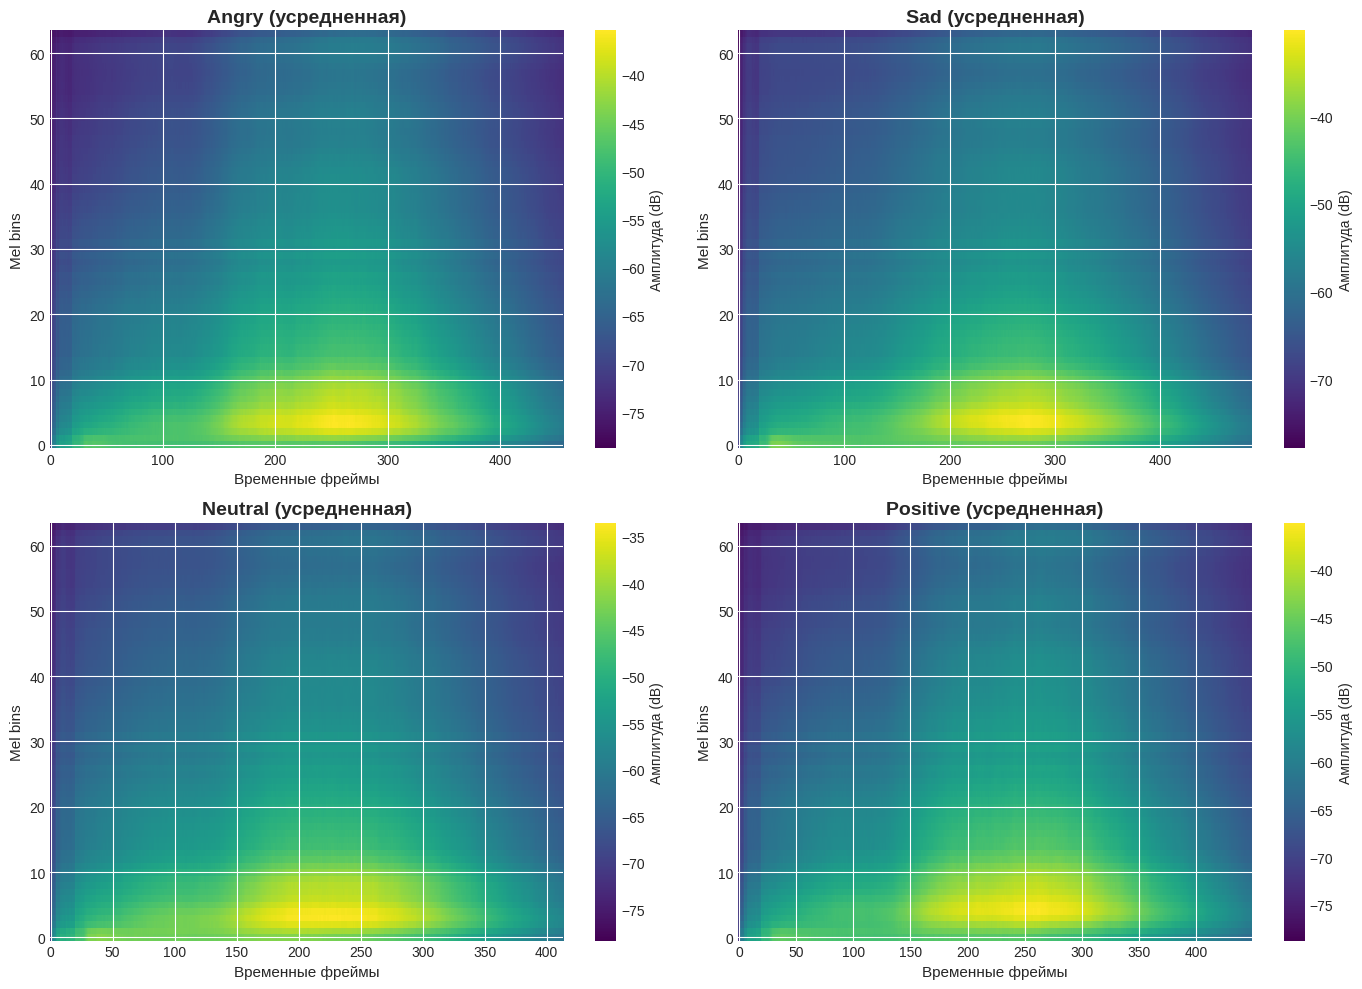

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes_flat = axes.flatten()
for idx, emotion in enumerate(TARGET_NAMES):
    if emotion not in avg_spectrograms:
        continue
    ax = axes_flat[idx]
    im = ax.imshow(avg_spectrograms[emotion], aspect='auto', origin='lower',
                   cmap='viridis', interpolation='nearest')
    ax.set_title(f'{emotion.capitalize()} (усредненная)', fontsize=14, fontweight='bold')
    ax.set_xlabel('Временные фреймы', fontsize=11)
    ax.set_ylabel('Mel bins', fontsize=11)
    plt.colorbar(im, ax=ax, label='Амплитуда (dB)')

plt.tight_layout()
plt.show()

## 3. Средние MFCC коэффициенты

In [6]:
def extract_mfcc_from_mel(mel_spec, n_mfcc=13):
    """Извлекает MFCC коэффициенты из mel-спектрограммы через DCT."""
    return dct(mel_spec, type=2, axis=0, norm='ortho')[:n_mfcc, :]

def compute_average_mfcc(features, labels, n_mfcc=13):
    """Вычисляет средние значения MFCC по эмоциям."""
    emotion_mfcc = {emo: [] for emo in TARGET_NAMES}
    
    for mel_spec, label in zip(features, labels):
        if label not in emotion_mfcc:
            continue
        if mel_spec.ndim == 3:
            mel_spec = mel_spec[0]
        mfcc = extract_mfcc_from_mel(mel_spec, n_mfcc)
        emotion_mfcc[label].append(np.mean(mfcc, axis=1))
    
    avg_mfcc, mfcc_stats = {}, {}
    for emotion, mfcc_list in emotion_mfcc.items():
        if not mfcc_list:
            continue
        mfcc_array = np.array(mfcc_list)
        avg_mfcc[emotion] = np.mean(mfcc_array, axis=0)
        mfcc_stats[emotion] = {
            'mean': np.mean(mfcc_array, axis=0),
            'std': np.std(mfcc_array, axis=0),
            'count': len(mfcc_list)
        }
        print(f"  {emotion:8s}: {len(mfcc_list)} сэмплов, MFCC форма: {avg_mfcc[emotion].shape}")
    
    return avg_mfcc, mfcc_stats

avg_mfcc, mfcc_stats = compute_average_mfcc(features, labels)

  angry   : 4344 сэмплов, MFCC форма: (13,)
  sad     : 6337 сэмплов, MFCC форма: (13,)
  neutral : 5564 сэмплов, MFCC форма: (13,)
  positive: 4229 сэмплов, MFCC форма: (13,)


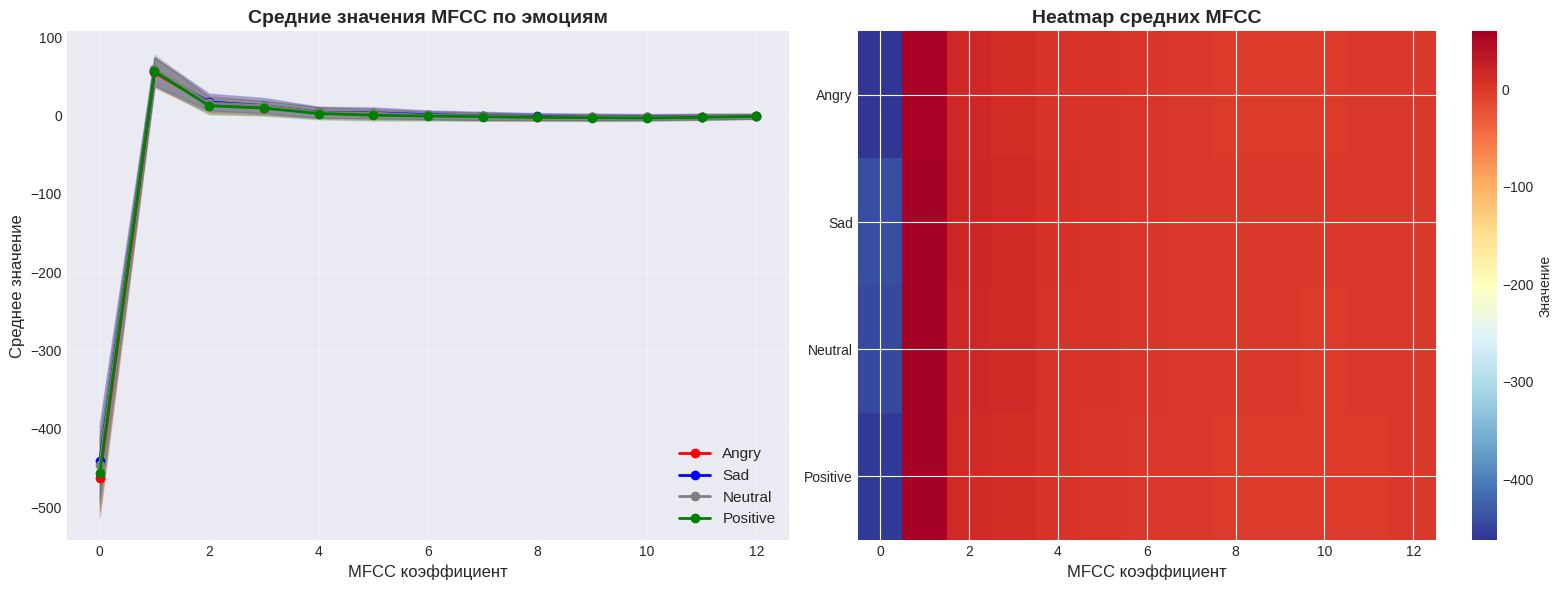

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Линейный график
for emotion in TARGET_NAMES:
    if emotion not in avg_mfcc:
        continue
    x = np.arange(len(mfcc_stats[emotion]['mean']))
    axes[0].plot(x, mfcc_stats[emotion]['mean'], marker='o', label=emotion.capitalize(),
                 color=EMOTION_COLORS[emotion], linewidth=2)
    axes[0].fill_between(x, mfcc_stats[emotion]['mean'] - mfcc_stats[emotion]['std'],
                         mfcc_stats[emotion]['mean'] + mfcc_stats[emotion]['std'],
                         alpha=0.2, color=EMOTION_COLORS[emotion])

axes[0].set_xlabel('MFCC коэффициент', fontsize=12)
axes[0].set_ylabel('Среднее значение', fontsize=12)
axes[0].set_title('Средние значения MFCC по эмоциям', fontsize=14, fontweight='bold')
axes[0].legend(loc='best', fontsize=11)
axes[0].grid(True, alpha=0.3)

# Heatmap
mfcc_matrix = np.array([avg_mfcc[e] for e in TARGET_NAMES if e in avg_mfcc])
emotion_order = [e.capitalize() for e in TARGET_NAMES if e in avg_mfcc]

im = axes[1].imshow(mfcc_matrix, aspect='auto', cmap='RdYlBu_r', interpolation='nearest')
axes[1].set_yticks(range(len(emotion_order)))
axes[1].set_yticklabels(emotion_order)
axes[1].set_xlabel('MFCC коэффициент', fontsize=12)
axes[1].set_title('Heatmap средних MFCC', fontsize=14, fontweight='bold')
plt.colorbar(im, ax=axes[1], label='Значение')

plt.tight_layout()
plt.show()

## 4. Подготовка признаков для визуализации

In [8]:
def prepare_features_for_visualization(features, labels):
    """Преобразует mel-спектрограммы в векторы для PCA/t-SNE."""
    feature_vectors, label_names = [], []
    
    for mel_spec, label in zip(features, labels):
        if mel_spec.ndim == 3:
            mel_spec = mel_spec[0]
        mean_part = mel_spec.mean(axis=1)
        std_part = mel_spec.std(axis=1)
        feature_vectors.append(np.concatenate([mean_part, std_part]))
        label_names.append(label)
    
    X = np.array(feature_vectors)
    y = np.array([EMO2LABEL[label] for label in label_names])
    
    print(f"Матрица признаков: {X.shape} (сэмплы × признаки)")
    return X, y, np.array(label_names)

X, y, label_names = prepare_features_for_visualization(features, labels)

Матрица признаков: (20474, 128) (сэмплы × признаки)


## 5. PCA визуализация

Объясненная дисперсия: PC1=50.52%, PC2=20.69%
Суммарная: 71.21%


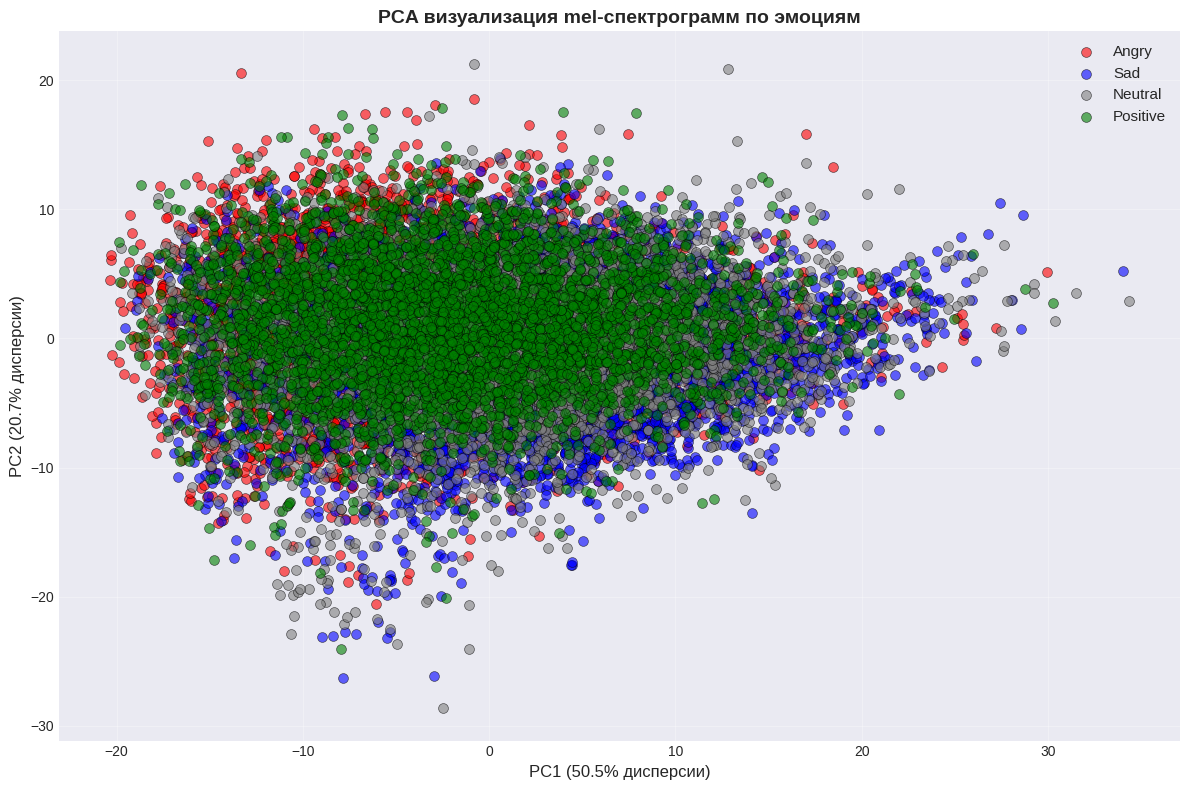

In [9]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

explained_var = pca.explained_variance_ratio_
print(f"Объясненная дисперсия: PC1={explained_var[0]*100:.2f}%, PC2={explained_var[1]*100:.2f}%")
print(f"Суммарная: {explained_var.sum()*100:.2f}%")

fig, ax = plt.subplots(figsize=(12, 8))
for emotion in TARGET_NAMES:
    mask = label_names == emotion
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1], c=EMOTION_COLORS[emotion],
               label=emotion.capitalize(), alpha=0.6, s=50, edgecolors='black', linewidth=0.5)

ax.set_xlabel(f'PC1 ({explained_var[0]*100:.1f}% дисперсии)', fontsize=12)
ax.set_ylabel(f'PC2 ({explained_var[1]*100:.1f}% дисперсии)', fontsize=12)
ax.set_title('PCA визуализация mel-спектрограмм по эмоциям', fontsize=14, fontweight='bold')
ax.legend(loc='best', fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 6. t-SNE визуализация

> t-SNE может занять несколько минут

[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 20474 samples in 0.001s...


[t-SNE] Computed neighbors for 20474 samples in 0.714s...
[t-SNE] Computed conditional probabilities for sample 1000 / 20474
[t-SNE] Computed conditional probabilities for sample 2000 / 20474
[t-SNE] Computed conditional probabilities for sample 3000 / 20474
[t-SNE] Computed conditional probabilities for sample 4000 / 20474
[t-SNE] Computed conditional probabilities for sample 5000 / 20474
[t-SNE] Computed conditional probabilities for sample 6000 / 20474


[t-SNE] Computed conditional probabilities for sample 7000 / 20474
[t-SNE] Computed conditional probabilities for sample 8000 / 20474
[t-SNE] Computed conditional probabilities for sample 9000 / 20474
[t-SNE] Computed conditional probabilities for sample 10000 / 20474
[t-SNE] Computed conditional probabilities for sample 11000 / 20474
[t-SNE] Computed conditional probabilities for sample 12000 / 20474
[t-SNE] Computed conditional probabilities for sample 13000 / 20474
[t-SNE] Computed conditional probabilities for sample 14000 / 20474
[t-SNE] Computed conditional probabilities for sample 15000 / 20474
[t-SNE] Computed conditional probabilities for sample 16000 / 20474
[t-SNE] Computed conditional probabilities for sample 17000 / 20474
[t-SNE] Computed conditional probabilities for sample 18000 / 20474
[t-SNE] Computed conditional probabilities for sample 19000 / 20474
[t-SNE] Computed conditional probabilities for sample 20000 / 20474
[t-SNE] Computed conditional probabilities for samp

[t-SNE] KL divergence after 250 iterations with early exaggeration: 96.057159


[t-SNE] KL divergence after 1000 iterations: 2.829885


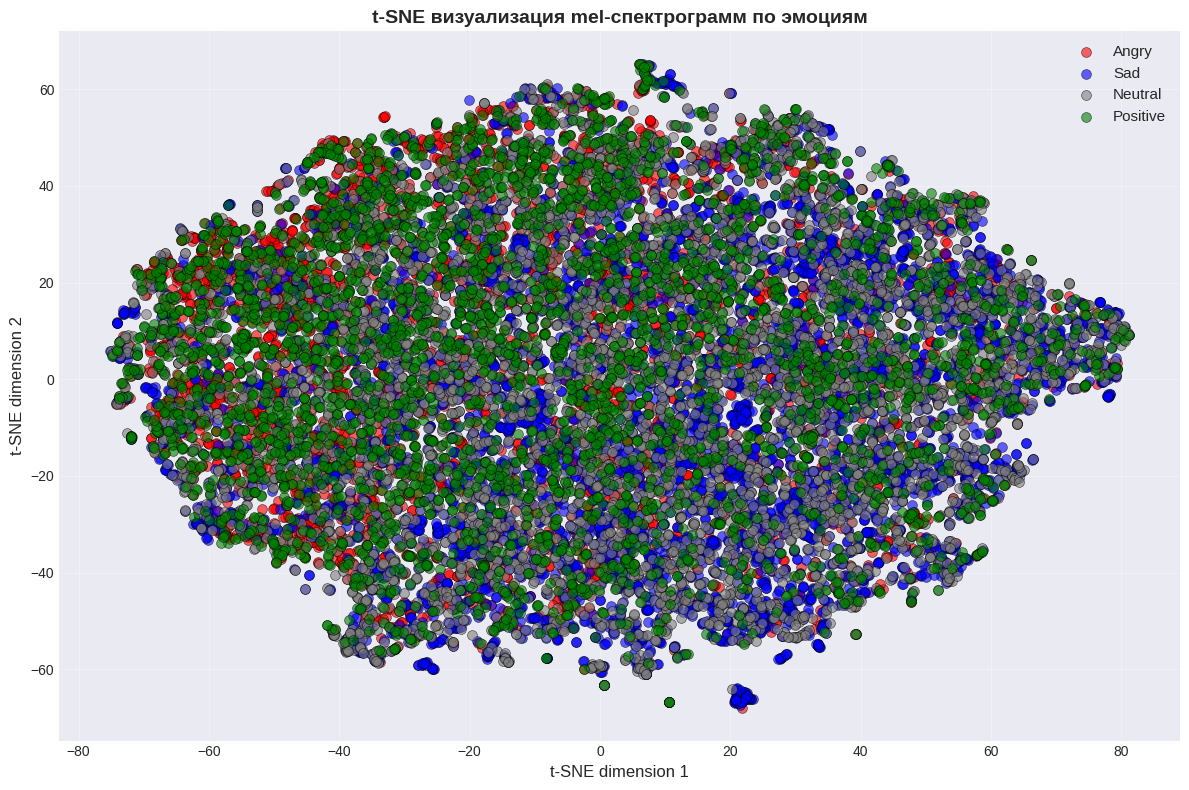

In [10]:
tsne = TSNE(n_components=2, perplexity=30, learning_rate=200,
            max_iter=1000, random_state=42, verbose=1)
X_tsne = tsne.fit_transform(X_scaled)

fig, ax = plt.subplots(figsize=(12, 8))
for emotion in TARGET_NAMES:
    mask = label_names == emotion
    ax.scatter(X_tsne[mask, 0], X_tsne[mask, 1], c=EMOTION_COLORS[emotion],
               label=emotion.capitalize(), alpha=0.6, s=50, edgecolors='black', linewidth=0.5)

ax.set_xlabel('t-SNE dimension 1', fontsize=12)
ax.set_ylabel('t-SNE dimension 2', fontsize=12)
ax.set_title('t-SNE визуализация mel-спектрограмм по эмоциям', fontsize=14, fontweight='bold')
ax.legend(loc='best', fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()